In [1]:
import sys
from pyprojroot import here

sys.path.insert(0, str(here()))

import pandas as pd
import numpy as np
import xarray as xr

import pymc as pm
import pytensor.tensor as pt
import pymc_extras as pmx
import matplotlib.pyplot as plt
import arviz as az

from scipy import sparse
from scipy.linalg import solve
from scipy.sparse.linalg import spsolve

from libpysal.weights import KNN, fuzzy_contiguity, w_union, W
import networkx as nx
import warnings

config = {
    'figure.figsize':(14,4),
    'figure.constrained_layout.use':True,
    'figure.facecolor':'w',
    'axes.grid':False,
    'grid.linewidth':0.5,
    'grid.linestyle':'--',
    'axes.spines.top':False,
    'axes.spines.bottom':False,
    'axes.spines.left':False,
    'axes.spines.right':False
}

plt.rcParams.update(config)

SEED = sum(list(map(ord, 'climate_bayes')))
rng = np.random.default_rng(SEED)

In [2]:
from laos_gggi import load_shapefile
from laos_gggi.replication_data import create_replication_data
from laos_gggi.data_functions import load_emdat_data, load_all_data
from laos_gggi.sample import sample_or_load

# Data loading and preparation

In [3]:
df = (create_replication_data()
        .rename(columns={'ISO':'iso'})
        .set_index(["iso", "year"]))

In [4]:
#Load shapefiles
world = (load_shapefile('world', repair_ISO_codes=True)
            .rename(columns={'ISO_A3':'iso'})
            .set_index('iso'))
laos = load_shapefile('laos')

## Dropping row missing covariates

There are years for which we don't have covariate data; these have to be dropped. We can keep missing damage and event data. These are probably zero, but maybe not. The pattern of missingness isn't random.

In [5]:
disasters = ["climatological_disasters", "hydrological_disasters"]
effects = ['Total_Damage_Adjusted_hydro', 'Total_Damage_Adjusted_clim']
features = ["ln_population_density", 
            "ln_gdp_pc", 
            "square_ln_gdp_p", 
            "precip_deviation", 
            "co2", 
            "population"]

In [6]:
df.dropna(subset=features, inplace=True)

## Reconcile EMDAT and shapefile ISO codes

In [7]:
df_iso = df.index.get_level_values('iso').unique()
world_iso = world.index.unique()

In [8]:
# Codes in EMDAT but not in world
", ".join(list(set(df_iso) - set(world_iso)))

''

In [9]:
# Codes in shapefile but not in EMDAT
", ".join(list(set(world_iso) - set(df_iso)))

'BMU, BLM, GIB, NRU, ABW, SGP, QAT, MCO, IMN, SMR, STP, TTO, VEN, AIA, MHL, FSM, FLK, BHS, MAC, LIE, GRD, PRI, ASM, ATG, SPM, CPV, SXM, KIR, GGY, SLB, LUX, PCN, DMA, MAF, TON, PSE, UNK, COM, AND, VAT, BRB, PLW, ISR, NIU, JAM, SHN, JEY, GRL, MNP, HKG, MLT, COK, ATF, WLF, VGB, CYP, HMD, CYM, NFK, BHR, IOT, MDV, MSR, TCA, FRO, LCA, CUW, KNA, SGS, VIR, VCT, PRK, GUM, SYC, TUV'

In [10]:
# Drop codes not in both
common_codes = set(world_iso).intersection(set(df_iso))

df = df.query('iso in @common_codes').copy()
world = world.query('iso in @common_codes').copy()

In [11]:
# Get unique iso codes and years
code_idx, codes = pd.factorize(df.index.get_level_values("iso"), sort=True)
year_idx, years = pd.factorize(df.index.get_level_values("year"), sort=True)

In [12]:
y = df[disasters].copy().astype(float)

# Assume years without observed disasters had no disasters.
# **THIS IS A TERRIBLE ASSUMPTION **
# but sampling is too onerous without it.
y_filled = y.fillna(0)

# Helper Functions

In [13]:
def plot_predictions(idata, 
                     iso: str,
                     group: str = 'posterior_predictive',
                     var_name: str = 'y_hat',
                     obs_name: str | None = None,
                     data: pd.DataFrame | None = None,
                     **kwargs):
    if group not in ['prior', 'posterior', 'prior_predictive', 'posterior_predictive']:
        raise ValueError(f'Invalid group {group}')
    
    if obs_name and data is None:
        obs_df = idata.observed_data.sel(obs_iso=iso)[obs_name].to_dataframe()[obs_name].unstack('disaster')
    elif data is not None:
        obs_df = data.xs(level=0, key=iso)
        
    iso_idata = idata[group][var_name].sel(obs_iso = iso)
    mu = iso_idata.mean(dim=['chain', 'draw'])
    
    index = mu['obs_year'].values
    disasters = mu['disaster'].values
    
    fig, ax = plt.subplots(1, 2, **kwargs)
    
    for disaster, axis in zip(disasters, fig.axes):
        axis.plot(index, mu.sel(disaster=disaster).values, color='tab:blue')

        if obs_name:
            axis.plot(index, obs_df[disaster].values, color='k', marker='o')
    
        for hdi_prob in np.linspace(0.05, 0.95, 25)[::-1]:
            hdi = az.hdi(iso_idata.sel(disaster=disaster), hdi_prob=hdi_prob)[var_name]
            axis.fill_between(index, *hdi.values.T, color='tab:blue', alpha=0.1)
        axis.set(xlabel="Year", ylabel = "Disaster Count", title=f"{iso} {disaster.title()}")

    plt.show();
    

# Dumb Model

idx = xr.Coordinates.from_pandas_multiindex(df.index.rename({'iso':'obs_iso', 'year':'obs_year'}), 'obs_idx')

coords = {
    'iso':codes,
    'year': [dt.year for dt in years],
    'disaster': ['climate', 'hydro'],
    'obs_idx': np.arange(df.shape[0])
}

with pm.Model(coords=coords, check_bounds=False) as model0:
    iso_idx_pt = pm.Data('iso_idx', code_idx, dims=['obs_idx'])
    year_idx_pt = pm.Data('year_idx', year_idx, dims=['obs_idx'])
    
    year_effect = pm.Normal('year_effect', 0, 1, dims=['year', 'disaster'])
    country_effect = pm.ZeroSumNormal('country_effect', 1, dims=['iso', 'disaster'])
    
    latent_rate = year_effect[year_idx_pt] + country_effect[iso_idx_pt]
    zero_prob = pm.Beta('zero_prob', alpha=1, beta=1, dims=['disaster'])
    
    mu = pm.Deterministic('mu', pt.softplus(latent_rate), dims=['obs_idx', 'disaster'])
    alpha = pm.Gamma('alpha', alpha=2, beta=1, dims=['disaster'])
    
    y_hat = pm.ZeroInflatedNegativeBinomial('y_hat',
                                            psi=zero_prob,
                                            mu=mu,
                                            alpha=alpha,
                                            observed=y_filled,
                                            dims=['obs_idx', 'disaster'])
    
    prior = pm.sample_prior_predictive().assign_coords(idx)

plot_predictions(prior, 
                 'LAO', 
                 'prior_predictive', 
                 obs_name='y_hat',
                 data=y_filled.set_axis(coords['disaster'], axis=1));

In [14]:
# Dictionary to store model results
results = {}

with model0:
    idata = sample_or_load(fp='idata/freq_model_0.nc',
                           sample_kwargs=dict(
                               init='jitter+adapt_diag_grad', 
                               cores=8,
                               chains=8, 
                               draws=250,
                               tune=250,
                               compile_kwargs={'mode':'NUMBA'},
                               ),
                           force_resample=False,
                           save_results=True,
                           compile_kwargs={'mode':'NUMBA'}
                          )
    idata = idata.assign_coords(idx)
    results['model0'] = idata

az.plot_trace(idata, var_names=['zero_prob', 'alpha', 'year_effect', 'country_effect']);

fig, ax = plt.subplots(1, 2, figsize=(14, 9), sharex=True, sharey=True)
for axis, disaster in zip(fig.axes, coords['disaster']):
    az.plot_forest(idata, var_names=['year_effect'], 
                   combined=True, 
                   labeller=az.labels.NoVarLabeller(),
                   coords={'disaster':[disaster]},
                   ax=axis)
    axis.set_title(disaster.title() + " Disasters, Year Effect")

fig, ax = plt.subplots(1, 2, figsize=(14, 9), sharex=True, sharey=True)
for axis, disaster in zip(fig.axes, coords['disaster']):
    az.plot_forest(idata, var_names=['country_effect'], 
                   combined=True, 
                   labeller=az.labels.NoVarLabeller(),
                   coords={'disaster':[disaster]},
                   ax=axis)
    axis.set_title(disaster.title() + " Disasters, Country Effect")

plot_predictions(idata, 
                 iso='LAO', 
                 obs_name='y_hat', 
                 data=y_filled.set_axis(coords['disaster'], axis=1))

# Partial Pooling

idx = xr.Coordinates.from_pandas_multiindex(df.index.rename({'iso':'obs_iso', 'year':'obs_year'}), 'obs_idx')

coords = {
    'iso':codes,
    'year': [dt.year for dt in years],
    'disaster': ['climate', 'hydro'],
    'obs_idx': np.arange(df.shape[0])
}

with pm.Model(coords=coords) as model1:
    iso_idx_pt = pm.Data('iso_idx', code_idx, dims=['obs_idx'])
    year_idx_pt = pm.Data('year_idx', year_idx, dims=['obs_idx'])
    
    year_loc = pm.Normal('year_loc', 0, 1, dims=['disaster'])
    year_scale = pm.Gamma('year_scale', alpha=2, beta=1, dims=['disaster'])
    year_offset = pm.Normal('year_offset', 0, 1, dims=['year', 'disaster'])
    
    year_effect = pm.Deterministic('year_effect', year_loc[None] + year_scale[None] * year_offset,
                                   dims=['year', 'disaster'])
    
    country_loc = pm.Normal('country_loc', 0, 1, dims=['disaster'])
    country_scale = pm.Gamma('country_scale', alpha=2, beta=1, dims=['disaster'])
    country_offset = pm.ZeroSumNormal('country_offset', 1, dims=['iso', 'disaster'])

    country_effect = pm.Deterministic('country_effect',
                                      country_loc[None] + country_scale[None] * country_offset, 
                                      dims=['iso', 'disaster'])
    
    latent_rate = year_effect[year_idx_pt] + country_effect[iso_idx_pt]
    zero_prob = pm.Beta('zero_prob', alpha=1, beta=1, dims=['disaster'])
    
    mu = pt.softplus(latent_rate)
    alpha = pm.Gamma('alpha', alpha=2, beta=1, dims=['disaster'])
    
    y_hat = pm.ZeroInflatedNegativeBinomial('y_hat',
                                            psi=zero_prob,
                                            mu=mu,
                                            alpha=alpha,
                                            observed=y_filled,
                                            dims=['obs_idx', 'disaster'])
    
    prior = pm.sample_prior_predictive().assign_coords(idx)

plot_predictions(prior, 
                 'LAO', 
                 'prior_predictive', 
                 obs_name='y_hat',
                 data=y_filled.set_axis(coords['disaster'], axis=1));

with model1:
    idata = sample_or_load(fp='idata/freq_model_1.nc',
                           sample_kwargs=dict(
                               init='jitter+adapt_diag_grad', 
                               cores=8,
                               chains=8, 
                               draws=250,
                               tune=250,
                               compile_kwargs={'mode':'NUMBA'}),
                           force_resample=False,
                           save_results=True,
                           compile_kwargs={'mode':'NUMBA'}
                          )
    idata = idata.assign_coords(idx)
    results['model1'] = idata

az.plot_trace(idata, var_names=['zero_prob', 'alpha', 'year_effect', 'country_effect']);

plot_predictions(idata, 
                 iso='LAO', 
                 obs_name='y_hat_observed', 
                 data=y_filled.set_axis(coords['disaster'], axis=1))

# Covariates Only

sigma = 2.5 * df[disasters].std().values[:, None] / df[features].std().values[None]

idx = xr.Coordinates.from_pandas_multiindex(df.index.rename({'iso':'obs_iso', 'year':'obs_year'}), 'obs_idx')

coords = {
    'iso':codes,
    'year': [dt.year for dt in years],
    'disaster': ['climate', 'hydro'],
    'obs_idx': np.arange(df.shape[0]),
    'feature':features
}

with pm.Model(coords=coords) as model2:
    X = pm.Data('X', df[features], dims=['obs_idx', 'feature'])
    
    intercept = pm.Normal('intercept', sigma=10)
    
    beta = pm.Normal('beta', 0, sigma.T, dims=['feature', 'disaster'])
    coef_effect = X @ beta
    
    latent_rate = intercept + coef_effect
    mu = pt.softplus(latent_rate)
    
    zero_prob = pm.Beta('zero_prob', alpha=1, beta=1, dims=['disaster'])
    alpha = pm.Gamma('alpha', alpha=2, beta=1, dims=['disaster'])
    
    y_hat = pm.ZeroInflatedNegativeBinomial('y_hat',
                                            psi=zero_prob,
                                            mu=pt.clip(mu, 1e-8, 300),
                                            alpha=alpha,
                                            observed=y_filled,
                                            dims=['obs_idx', 'disaster'])
    
    prior = pm.sample_prior_predictive().assign_coords(idx)

plot_predictions(prior, 
                 'LAO', 
                 'prior_predictive',
                 obs_name='y_hat_observed', 
                 data=y_filled.set_axis(coords['disaster'], axis=1));

with model2:
    idata = sample_or_load(fp='idata/freq_model_2.nc',
                           sample_kwargs=dict(
                               nuts_sampler='nutpie', 
#                                init='jitter+adapt_diag_grad',
                               cores=8,
                               chains=8, 
                               draws=250,
                               tune=500,
#                                compile_kwargs={'mode':'NUMBA'}
                               nuts_sampler_kwargs={'backend':'jax'}
                               ),
                           force_resample=False,
                           save_results=True,
                           compile_kwargs={'mode':'NUMBA'},
                          )
    idata = idata.assign_coords(idx)
    results['model2'] = idata

az.plot_trace(idata, var_names=['alpha', 'beta', 'zero_prob'], filter_vars='like');

fig, ax = plt.subplots(1, 2, figsize=(14, 4), sharex=True, sharey=True)
for axis, disaster in zip(fig.axes, coords['disaster']):
    az.plot_forest(idata, var_names=['beta'], 
                   combined=True, 
                   labeller=az.labels.NoVarLabeller(),
                   coords={'disaster':[disaster]},
                   ax=axis)
    axis.set_title(disaster.title() + " Disasters, Country Effect")

plot_predictions(idata, 
                 iso='LAO', 
                 obs_name='y_hat_observed', 
                 data=y_filled.set_axis(coords['disaster'], axis=1))

## Time FE vs CO2

fig, ax = plt.subplots(1, 2)
time_effect = results['model1'].posterior.year_effect
time_mu = time_effect.mean(dim=['chain', 'draw'])
time_hdi = az.hdi(time_effect).year_effect

co2_beta = results['model2'].posterior.beta.sel(feature='co2')
co2_data = co2_beta * df['co2'].unstack('iso')['USA'].sort_index().to_xarray() #.transform(lambda x: (x - x.mean()) / x.std())

co2_mu = co2_data.mean(dim=['chain', 'draw'])
co2_hdi = az.hdi(co2_data).x

for axis, disaster in zip(fig.axes, coords['disaster']):
    axis.scatter(years, time_mu.sel(disaster=disaster))
    axis.vlines(years, *time_hdi.sel(disaster=disaster).values.T)
    axis.set(title=disaster)
    
    axis2 = axis.twinx()
    axis2.plot(years, co2_mu.sel(disaster=disaster), color='tab:red')    
    axis2.fill_between(years, *co2_hdi.sel(disaster=disaster).values.T, color='tab:red', alpha=0.2)    

    

# Panel + Covariates

In [15]:
idx = xr.Coordinates.from_pandas_multiindex(df.index.rename({'iso':'obs_iso', 'year':'obs_year'}), 'obs_idx')

features = ["ln_population_density", 
               "ln_gdp_pc", 
               "square_ln_gdp_p", 
               "precip_deviation", 
               "co2", 
               "population"]

coords = {
    'iso':codes,
    'year': [dt.year for dt in years],
    'disaster': ['climate', 'hydro'],
    'obs_idx': np.arange(df.shape[0]),
    'feature':features,
    'latent': ['iso', 'year']
}



with pm.Model(coords=coords) as model3:
    X = pm.Data('X', df[features])
    iso_idx_pt = pm.Data('iso_idx', code_idx, dims=['obs_idx'])

    # Mundlak Adjustment
    latent_iso = pm.Normal('latent_iso', 1, dims=['iso', 'feature'])
    
    alpha_X = pm.Normal('alpha_X', 0, 1, dims=['feature'])
    sigma_X = pm.Exponential('sigma_X', 1, dims=['feature'])
    
    mu_X = alpha_X + latent_iso[iso_idx_pt]
    pm.Normal('X_hat', mu=mu_X, sigma=sigma_X, observed=X)
    
    # Actual Model    
    # Drop year FE; it's the same as the co2 effect
    country_loc = pm.Normal('country_loc', 0, 1, dims=['disaster'])
    country_scale = pm.Gamma('country_scale', alpha=2, beta=1, dims=['disaster'])
    country_offset = pm.ZeroSumNormal('country_offset', 1, dims=['iso', 'disaster'])

    country_effect = pm.Deterministic('country_effect',
                                      country_loc[None] + country_scale[None] * country_offset, 
                                      dims=['iso', 'disaster'])
    
    
    beta_sigma = 2.5 / df[features].std().values[None] * df[disasters].std().values[:, None]
    beta = pm.Normal('beta', 0, beta_sigma.T, dims=['feature', 'disaster'])
    beta_GY = pm.Normal('beta_GY', 0, 1, dims=['feature', 'disaster'])    
    coef_effect = X @ beta + (latent_iso @ beta_GY)[iso_idx_pt]
    
    latent_rate = country_effect[iso_idx_pt] + coef_effect
    
    mu = pt.softplus(latent_rate)
    
    zero_prob = pm.Beta('zero_prob', alpha=1, beta=1, dims=['disaster'])
    alpha = pm.Gamma('alpha', alpha=2, beta=1, dims=['disaster'])
    
    y_hat = pm.ZeroInflatedNegativeBinomial('y_hat',
                                            psi=zero_prob,
                                            mu=pt.clip(mu, 1e-6, 300),
                                            alpha=alpha,
#                                             observed=df[disasters],
                                            observed=y_filled,
                                            dims=['obs_idx', 'disaster'])
    
    prior = pm.sample_prior_predictive().assign_coords(idx)

Sampling: [X_hat, alpha, alpha_X, beta, beta_GY, country_loc, country_offset, country_scale, latent_iso, sigma_X, y_hat, zero_prob]


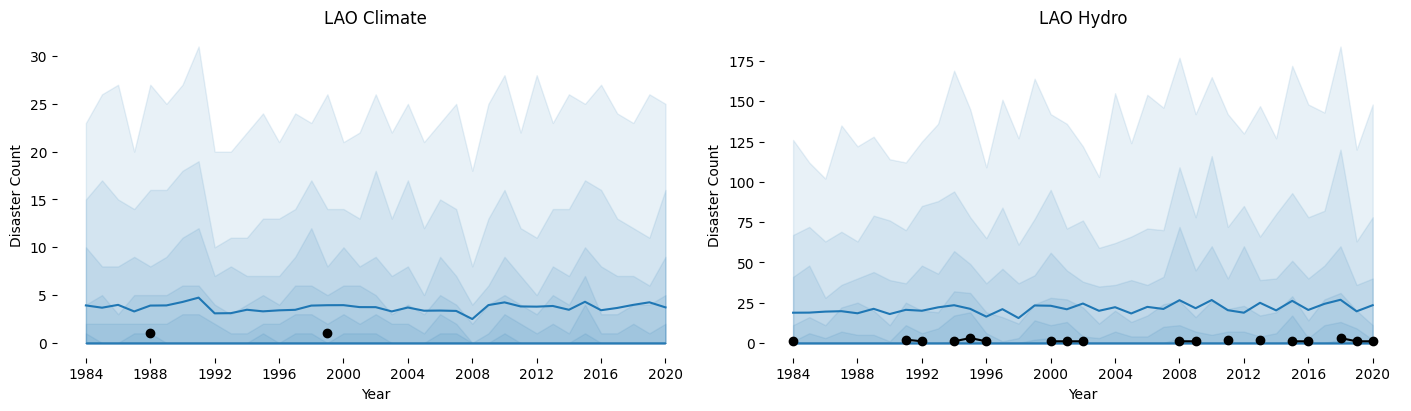

In [16]:
plot_predictions(prior, 'LAO', 
                 'prior_predictive',
                 obs_name='y_hat', 
                 data=y.set_axis(coords['disaster'], axis=1));

In [17]:
with model3:
    idata = sample_or_load(fp='idata/freq_model_3.nc',
                           sample_kwargs=dict(
#                                nuts_sampler='nutpie', 
                               init='jitter+adapt_diag_grad',
                               cores=8,
                               chains=8, 
                               draws=250,
                               tune=500,
#                                nuts_sampler_kwargs={'backend':'numba'}
                               compile_kwargs={'mode':'NUMBA'}
                               ),
                           force_resample=False,
                           save_results=True,
                           compile_kwargs={'mode':'NUMBA'},
                          )
    idata = idata.assign_coords(idx)
    results['model3'] = idata

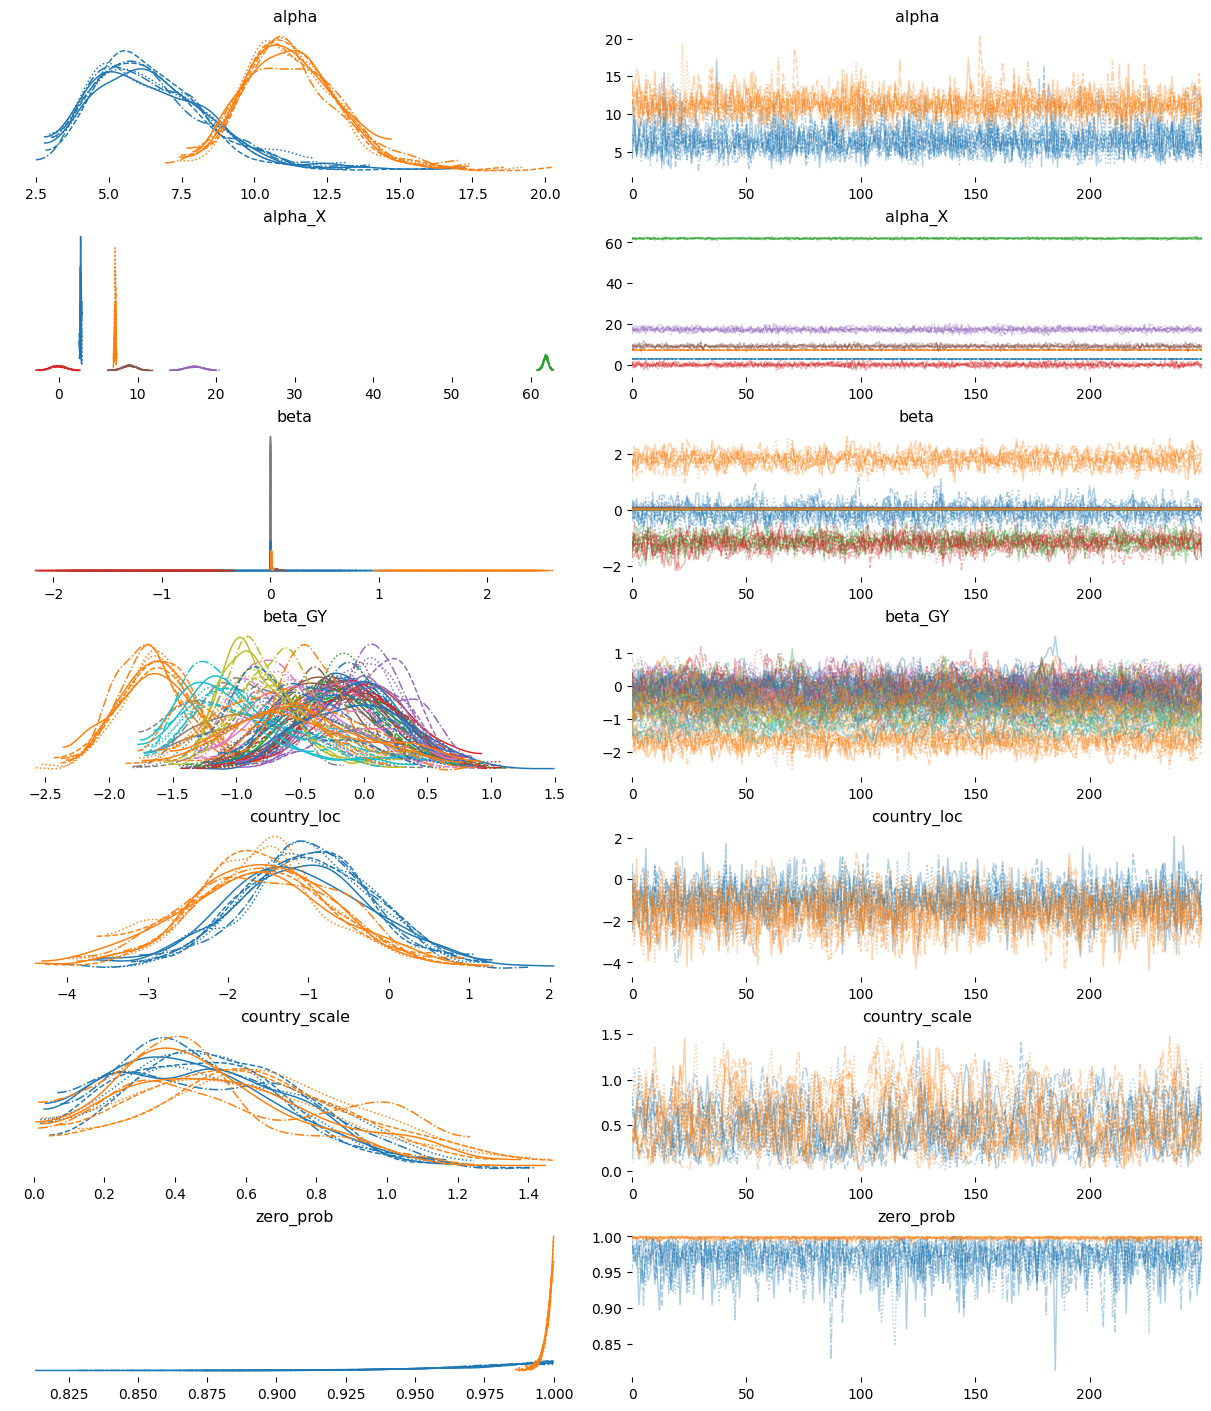

In [18]:
az.plot_trace(idata, 
              var_names=['country_loc', 'country_scale', 'alpha', 'beta', 'zero_prob', 'latent_loc'], 
              filter_vars='regex');

In [19]:
summary = az.summary(idata)
summary.sort_values(by='r_hat', ascending=False).head(30)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha_X[ln_population_density],2.774,0.075,2.642,2.923,0.018,0.009,17.0,35.0,1.43
alpha_X[ln_gdp_pc],7.153,0.079,7.004,7.302,0.019,0.011,18.0,24.0,1.40
"latent_iso[MMR, ln_population_density]",1.441,0.084,1.285,1.601,0.019,0.008,20.0,52.0,1.32
"latent_iso[AGO, ln_population_density]",-0.178,0.084,-0.328,-0.008,0.019,0.008,20.0,49.0,1.32
"latent_iso[COL, ln_population_density]",0.764,0.084,0.599,0.914,0.019,0.008,20.0,50.0,1.32
"latent_iso[URY, ln_population_density]",0.138,0.084,-0.019,0.296,0.019,0.008,20.0,47.0,1.32
"latent_iso[ZAF, ln_population_density]",0.862,0.085,0.703,1.022,0.019,0.008,20.0,56.0,1.32
"latent_iso[SWZ, ln_population_density]",1.262,0.084,1.109,1.430,0.019,0.008,20.0,49.0,1.32
"latent_iso[NIC, ln_population_density]",0.934,0.083,0.780,1.090,0.019,0.008,20.0,54.0,1.32
"latent_iso[BOL, ln_population_density]",-0.704,0.084,-0.849,-0.540,0.019,0.007,20.0,74.0,1.32


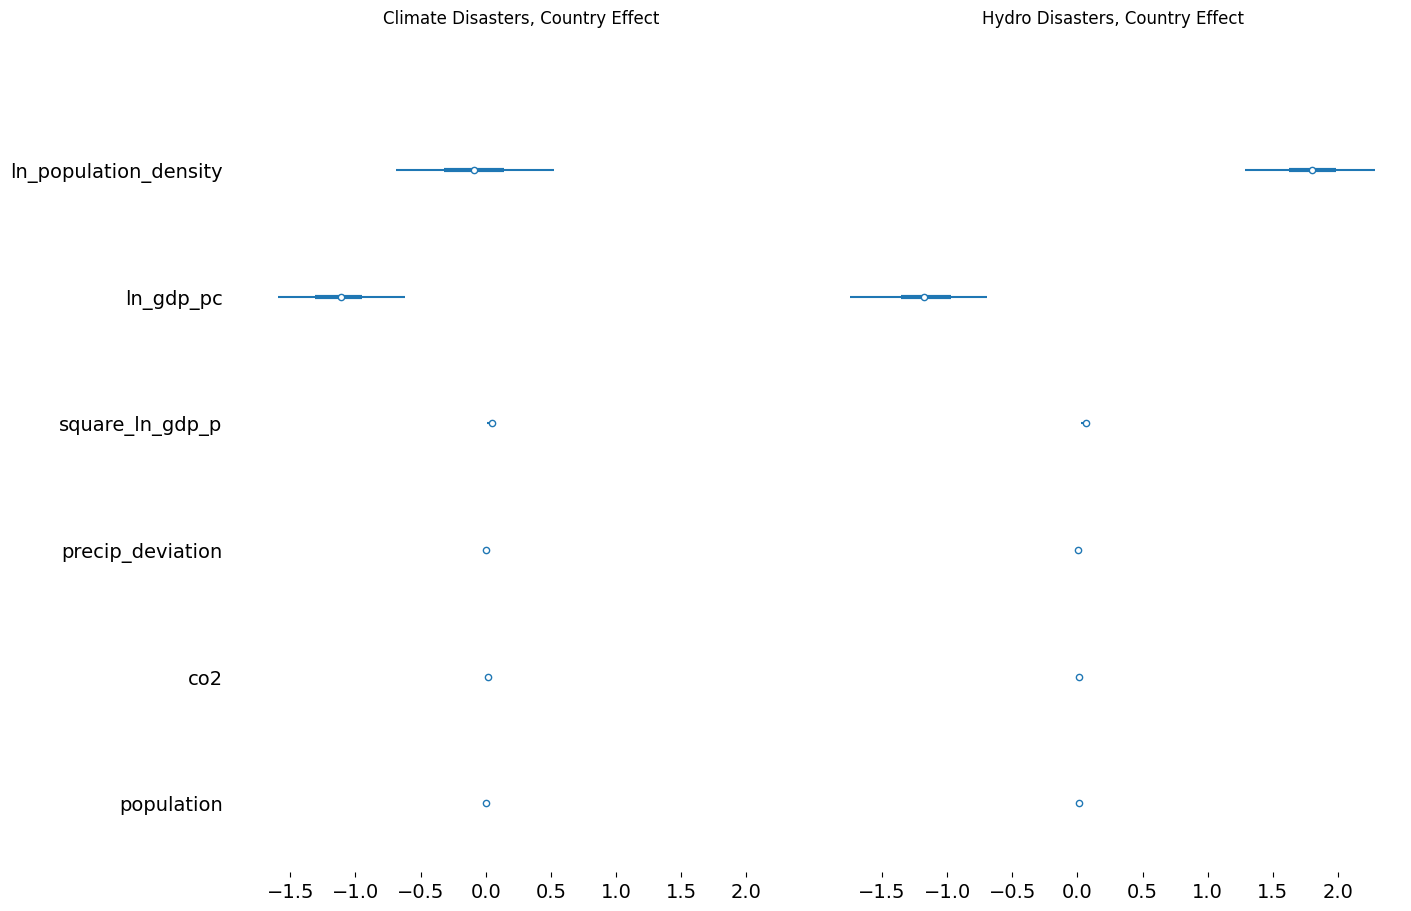

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(14, 9), sharex=True, sharey=True)
for axis, disaster in zip(fig.axes, coords['disaster']):
    az.plot_forest(idata, var_names=['beta'], 
                   combined=True, 
                   labeller=az.labels.NoVarLabeller(),
                   coords={'disaster':[disaster]},
                   ax=axis)
    axis.set_title(disaster.title() + " Disasters, Country Effect")

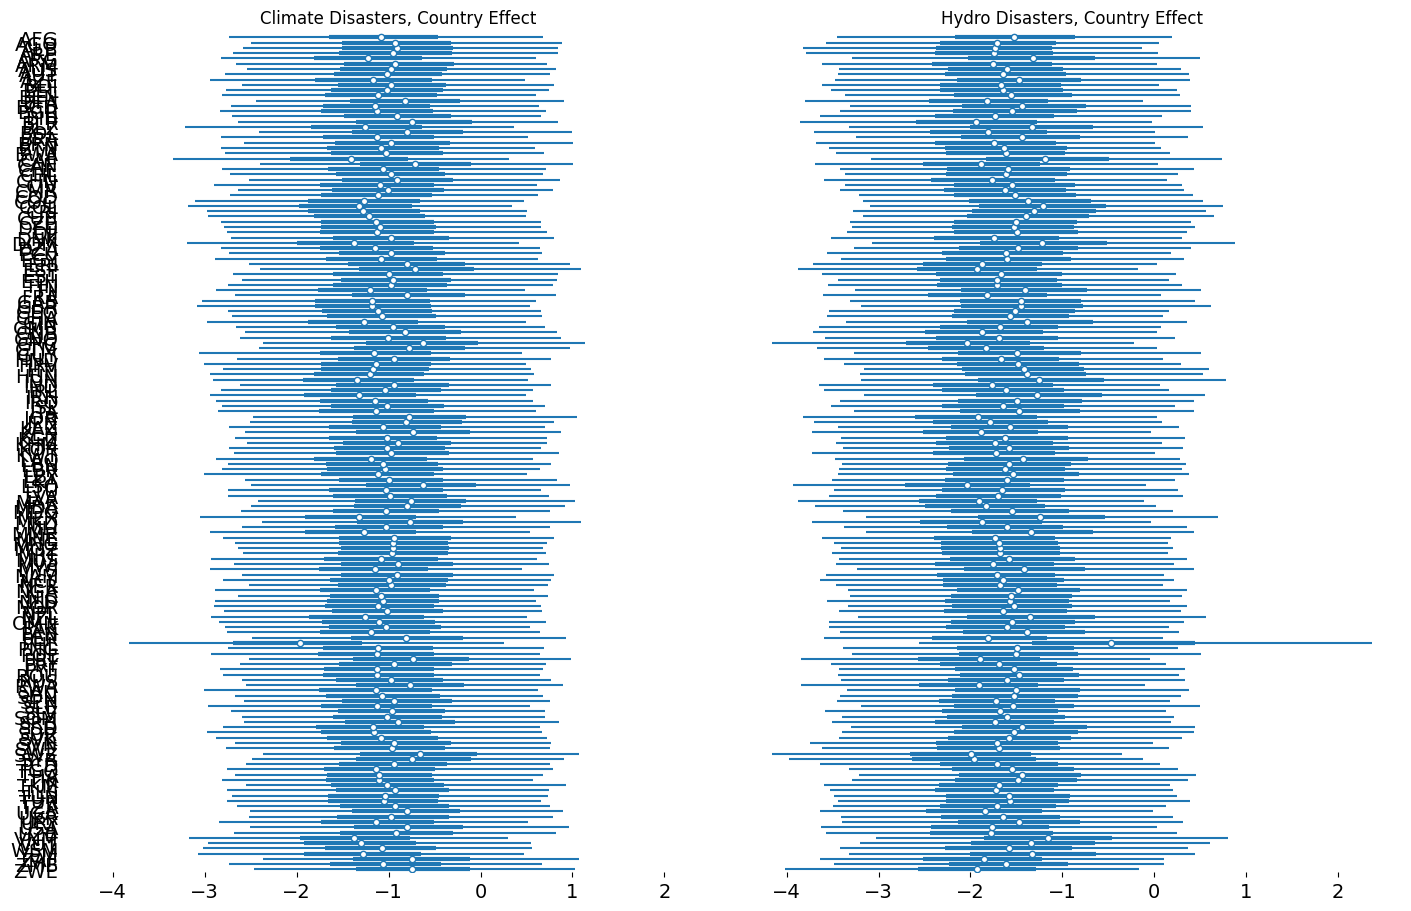

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(14, 9), sharex=True, sharey=True)
for axis, disaster in zip(fig.axes, coords['disaster']):
    az.plot_forest(idata, var_names=['country_effect'], 
                   combined=True, 
                   labeller=az.labels.NoVarLabeller(),
                   coords={'disaster':[disaster]},
                   ax=axis)
    axis.set_title(disaster.title() + " Disasters, Country Effect")

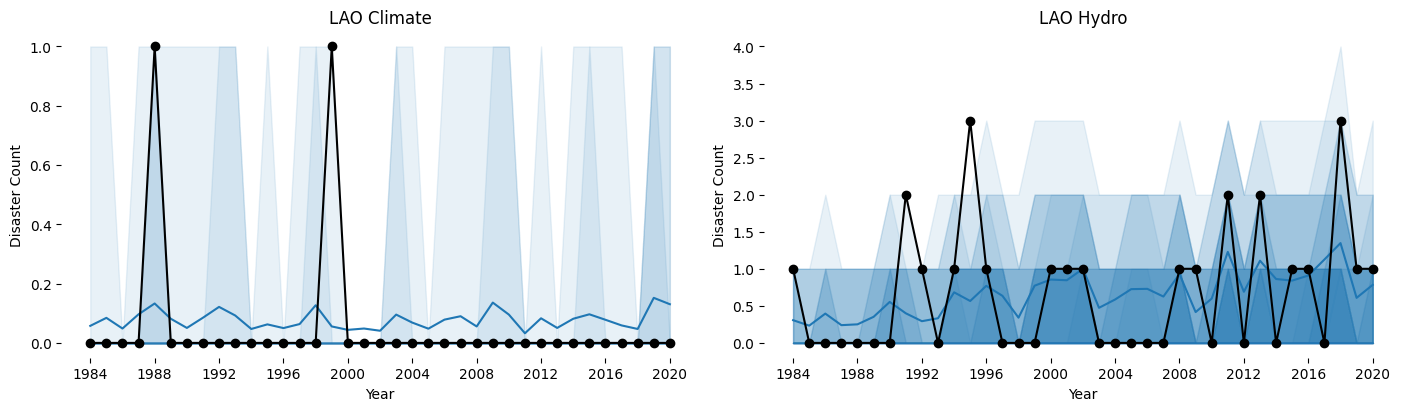

In [22]:
plot_predictions(idata, 
                 iso='LAO', 
                 obs_name='y_hat_observed', 
                 data=y_filled.set_axis(coords['disaster'], axis=1))

az.compare(results, var_name='y_hat')

# ICAR Mixin

## Nodes and adjacency matrix

In [24]:
with warnings.catch_warnings(action='ignore'):
    # Make graph of bordering countires
    w1 = fuzzy_contiguity(world)
    
    # Robustness of statistics to choice of k?
    w2 = KNN.from_dataframe(world, k=3)
    w = w_union(w1, w2)
    keys = sorted(list(w.neighbors.keys()))
    
    G = w.to_networkx().to_undirected()
    
    # Discard all but the main connected component (largest connected subgraph)
    G = nx.subgraph(G, list(nx.connected_components(G))[0])
    
    # Make a dataset of only the regions in the resulting graph
    connected_world = world.iloc[list(G.nodes)].copy()
    idx_to_name = dict(enumerate(keys))
    
    # Change node names from numbers to ISO codes and do a sanity check
    G = nx.relabel_nodes(G, idx_to_name)
    #assert list(G['USA'].keys()) == ['CAN', 'MEX']
    
    
    # Compute the weight matrix resulting from the graph and do a sanity check
    w = W.from_networkx(G)
    w.remap_ids(list(G.nodes))
    #assert w.neighbors['USA'] == ['CAN', 'MEX']

In [25]:
iso_mean = (idata.posterior_predictive
                .y_hat
                .mean(dim=['chain', 'draw'])
                .groupby('obs_iso')
                .mean()
                .to_dataframe()
                .loc[:, 'y_hat']
                .unstack('disaster'))

d = iso_mean.to_dict()

In [26]:
iso_mean.describe()

disaster,climate,hydro
count,159.000000,159.000000
mean,0.103182,0.763837
std,0.116507,1.322373
min,0.004825,0.013150
25%,0.023140,0.151325
50%,0.061925,0.376224
75%,0.152706,0.853450
max,0.909512,10.954512


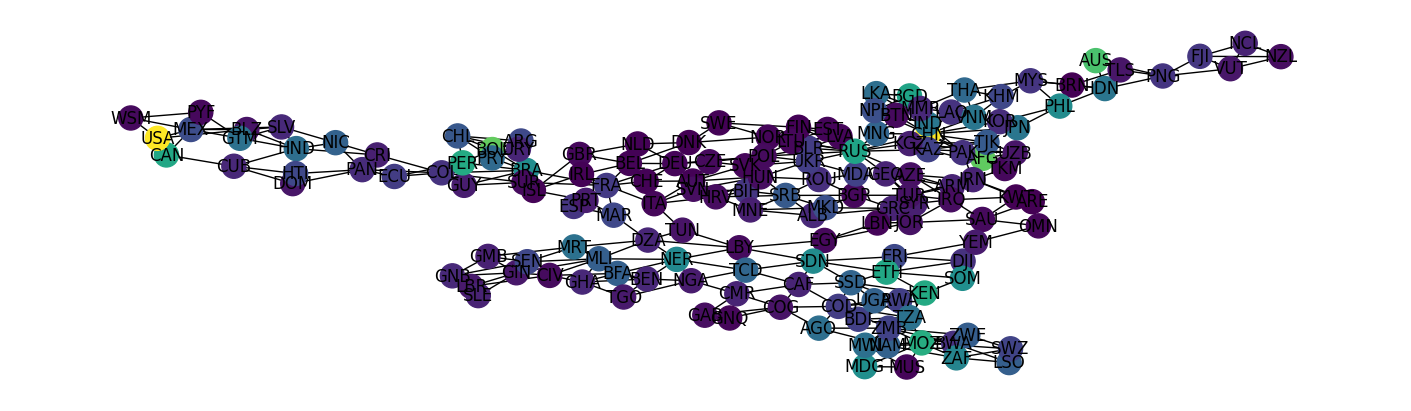

In [27]:
from networkx.drawing.nx_pydot import graphviz_layout
pos = graphviz_layout(G, prog='neato')
nx.draw_networkx(G, pos=pos, node_color=[d['climate'].get(n) for n in G.nodes], vmax=0.5)

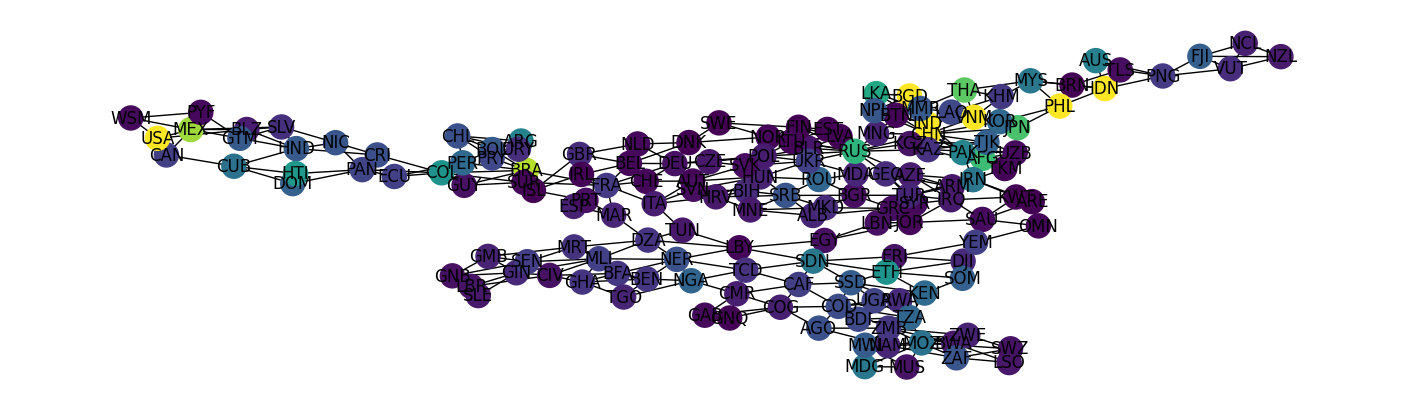

In [28]:
from networkx.drawing.nx_pydot import graphviz_layout
pos = graphviz_layout(G, prog='neato')
nx.draw_networkx(G, pos=pos, node_color=[d['hydro'].get(n) for n in G.nodes], vmax=3)

In [29]:
#Scaling factor function
def scaling_factor_sp(A):
    """Compute the scaling factor from an adjacency matrix.
    This function uses sparse matrix computations and is most
    efficient on sparse adjacency matrices. Used in the BYM2 model.
    The scaling factor is a measure of the variance in the number of
    edges across nodes in a connected graph.
    Only works for fully connected graphs. The argument for scaling
    factors is developed by Andrea Riebler, Sigrunn H. Sørbye,
    Daniel Simpson, Havard Rue in "An intuitive Bayesian spatial
    model for disease mapping that accounts for scaling"
    https://arxiv.org/abs/1601.01180"""

    # Computes the precision matrix in sparse format
    # from an adjacency matrix.

    num_neighbors = A.sum(axis=1)
    A = sparse.csc_matrix(A)
    D = sparse.diags(num_neighbors, format="csc")
    Q = D - A

    # add a small jitter along the diagonal

    Q_perturbed = Q + sparse.diags(np.ones(Q.shape[0])) * max(Q.diagonal()) * np.sqrt(
        np.finfo(np.float64).eps
    )

    # Compute a version of the pseudo-inverse

    n = Q_perturbed.shape[0]
    b = sparse.identity(n, format="csc")
    Sigma = spsolve(Q_perturbed, b)
    A = np.ones(n)
    W = Sigma @ A.T
    Q_inv = Sigma - np.outer(W * solve(A @ W, np.ones(1)), W.T)

    # Compute the geometric mean of the diagonal on a
    # precision matrix.

    return np.exp(np.sum(np.log(np.diag(Q_inv))) / n)

In [32]:
idx = xr.Coordinates.from_pandas_multiindex(df.index.rename({'iso':'obs_iso', 'year':'obs_year'}), 'obs_idx')

features = ["ln_population_density", 
               "ln_gdp_pc", 
               "square_ln_gdp_p", 
               "precip_deviation", 
               "co2", 
               "population"]

coords = {
    'iso':codes,
    'year': [dt.year for dt in years],
    'disaster': ['climate', 'hydro'],
    'obs_idx': np.arange(df.shape[0]),
    'feature':features,
    'latent': ['iso', 'year']
}


with pm.Model(coords=coords) as model4:
    X = pm.Data('X', df[features])
    iso_idx_pt = pm.Data('iso_idx', code_idx, dims=['obs_idx'])

    # Mundlak Adjustment
    latent_iso = pm.Normal('latent_iso', 1, dims=['iso', 'feature'])
    
    alpha_X = pm.Normal('alpha_X', 0, 1, dims=['feature'])
    sigma_X = pm.Exponential('sigma_X', 1, dims=['feature'])
    
    mu_X = alpha_X + latent_iso[iso_idx_pt]
    pm.Normal('X_hat', mu=mu_X, sigma=sigma_X, observed=X)
    
    # Actual Model    
    country_loc = pm.Normal('country_loc', 0, 1, dims=['disaster'])
    country_scale = pm.Gamma('country_scale', alpha=2, beta=1, dims=['disaster'])
    country_offset = pm.ZeroSumNormal('country_offset', 1, dims=['iso', 'disaster'])

    country_effect = pm.Deterministic('country_effect',
                                      country_loc[None] + country_scale[None] * country_offset, 
                                      dims=['iso', 'disaster'])
    
    
    beta_sigma = 2.5 / df[features].std().values[None] * df[disasters].std().values[:, None]
    beta = pm.Normal('beta', 0, beta_sigma.T, dims=['feature', 'disaster'])
    beta_GY = pm.Normal('beta_GY', 0, 1, dims=['feature', 'disaster'])    
    coef_effect = X @ beta + (latent_iso @ beta_GY)[iso_idx_pt]
    
    # ICAR Mixin
    A = nx.adjacency_matrix(G)
    theta = pm.Normal("theta", mu = 0, sigma = 1, dims = ["iso", 'disaster'])
    phi = [pm.ICAR(f"phi_{disaster}", W = A.todense(), dims = ["iso"]) for disaster in disasters]
    phi = pm.Deterministic('phi', pt.stack(phi).T, dims=['iso', 'disaster'])
    rho = pm.Beta("rho", 0.5, 0.5, dims=['disaster'])
    mixture = pm.Deterministic("mixture", pt.sqrt(1 - rho[None]) * theta + 
                               pt.sqrt(rho[None] / scaling_factor_sp(A)) *  phi, 
                               dims = ["iso", 'disaster'])

    latent_rate = (country_effect + mixture)[iso_idx_pt] + coef_effect
    mu = pt.softplus(latent_rate)
    
    zero_prob = pm.Beta('zero_prob', alpha=1, beta=1, dims=['disaster'])
    alpha = pm.Gamma('alpha', alpha=2, beta=1, dims=['disaster'])
    
    y_hat = pm.ZeroInflatedNegativeBinomial('y_hat',
                                            psi=zero_prob,
                                            mu=pt.clip(mu, 1e-6, 300),
                                            alpha=alpha,
                                            observed=y_filled,
                                            dims=['obs_idx', 'disaster'])

# Can't prior predictive sample with ICAR priors
#     prior = pm.sample_prior_predictive().assign_coords(idx)

In [33]:
with model4:
    idata = sample_or_load(fp='idata/freq_model_4_1000.nc',
                           sample_kwargs=dict(
#                                nuts_sampler='nutpie', 
                               # init='jitter+adapt_diag_grad',
                               cores=8,
                               chains=8, 
                               draws=1000,
                               tune=1000,
                               # compile_kwargs={'mode':'NUMBA'}
#                                nuts_sampler_kwargs={'backend':'numba'}
                               ),
                           force_resample=False,
                           save_results=True,
                           compile_kwargs={'mode':'NUMBA'},
                          )
    idata = idata.assign_coords(idx)
    results['model4'] = idata

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (8 chains in 8 jobs)
NUTS: [latent_iso, alpha_X, sigma_X, country_loc, country_scale, country_offset, beta, beta_GY, theta, phi_climatological_disasters, phi_hydrological_disasters, rho, zero_prob, alpha]


Output()

Sampling 8 chains for 1_000 tune and 1_000 draw iterations (8_000 + 8_000 draws total) took 4498 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
C:\Users\camil\miniforge3\envs\laos-climate-change\Lib\site-packages\pytensor\link\numba\dispatch\basic.py:373: UserWarning: Numba will use object mode to run AdvancedSubtensor's perform method
  warnings.warn(
Sampling: [X_hat, y_hat]


Output()

Output()

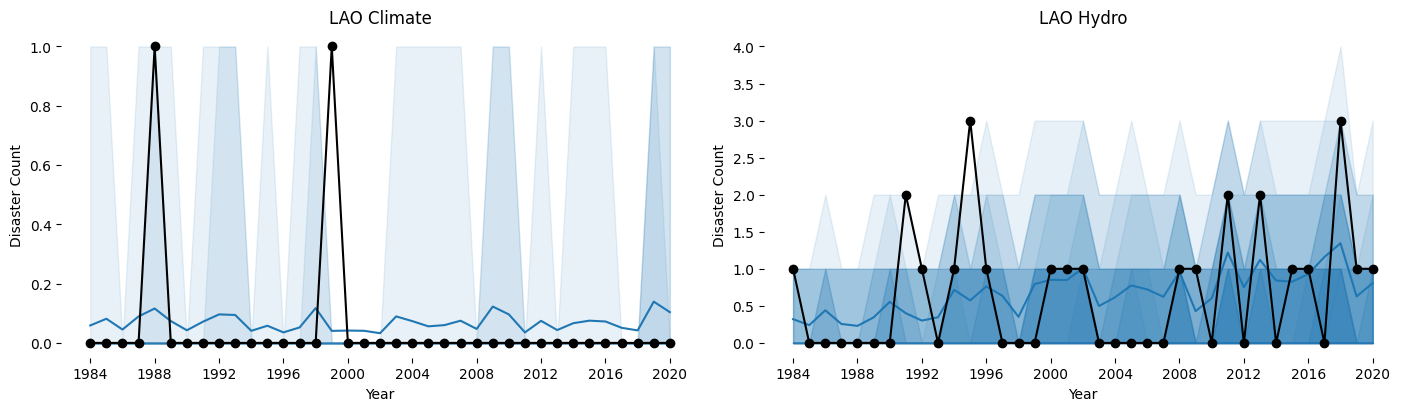

In [34]:
plot_predictions(idata, 
                 iso='LAO', 
                 obs_name='y_hat_observed', 
                 data=y_filled.set_axis(coords['disaster'], axis=1))

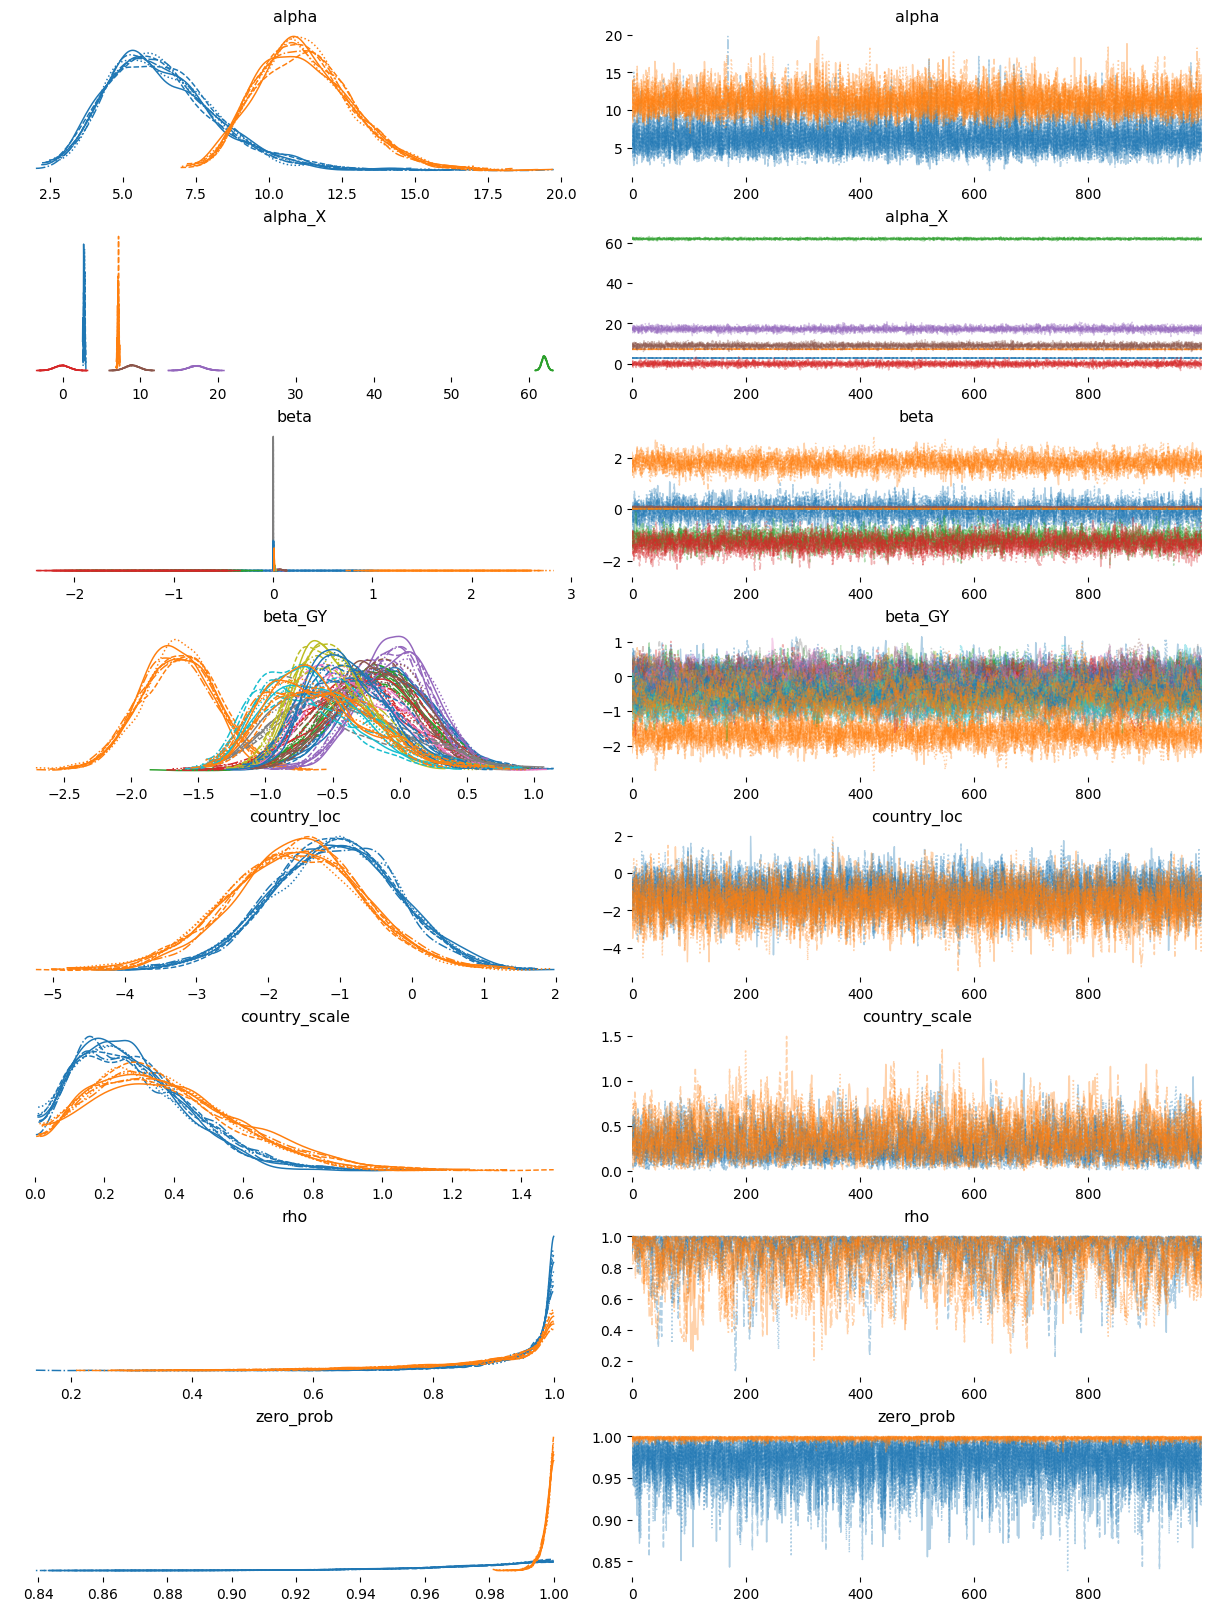

In [35]:
az.plot_trace(idata, 
              var_names=['country_loc', 'country_scale', 'alpha', 'beta', 'zero_prob', 'latent_loc', 'rho'], 
              filter_vars='regex');

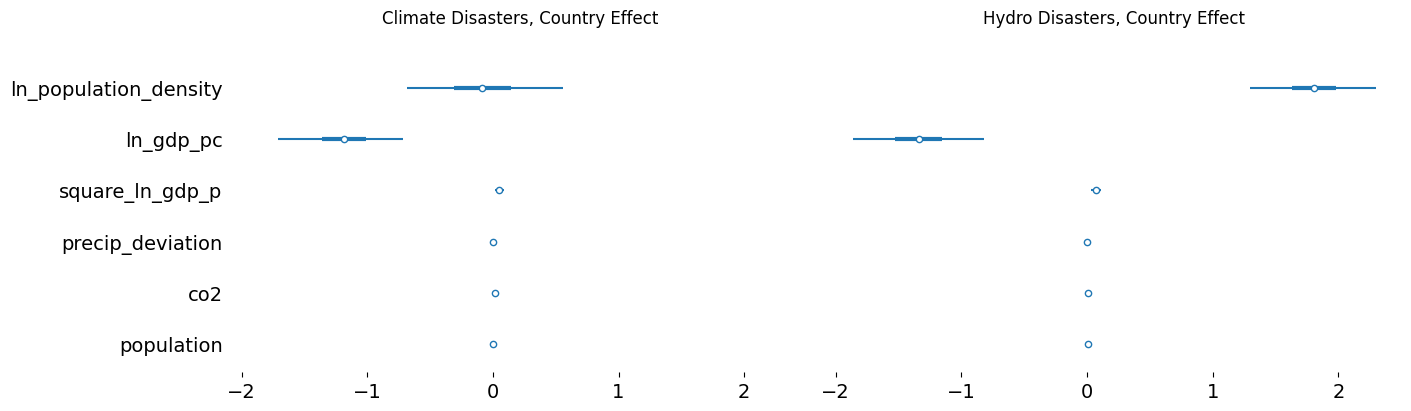

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4), sharex=True, sharey=True)
for axis, disaster in zip(fig.axes, coords['disaster']):
    az.plot_forest(idata, var_names=['beta'], 
                   combined=True, 
                   labeller=az.labels.NoVarLabeller(),
                   coords={'disaster':[disaster]},
                   ax=axis)
    axis.set_title(disaster.title() + " Disasters, Country Effect")

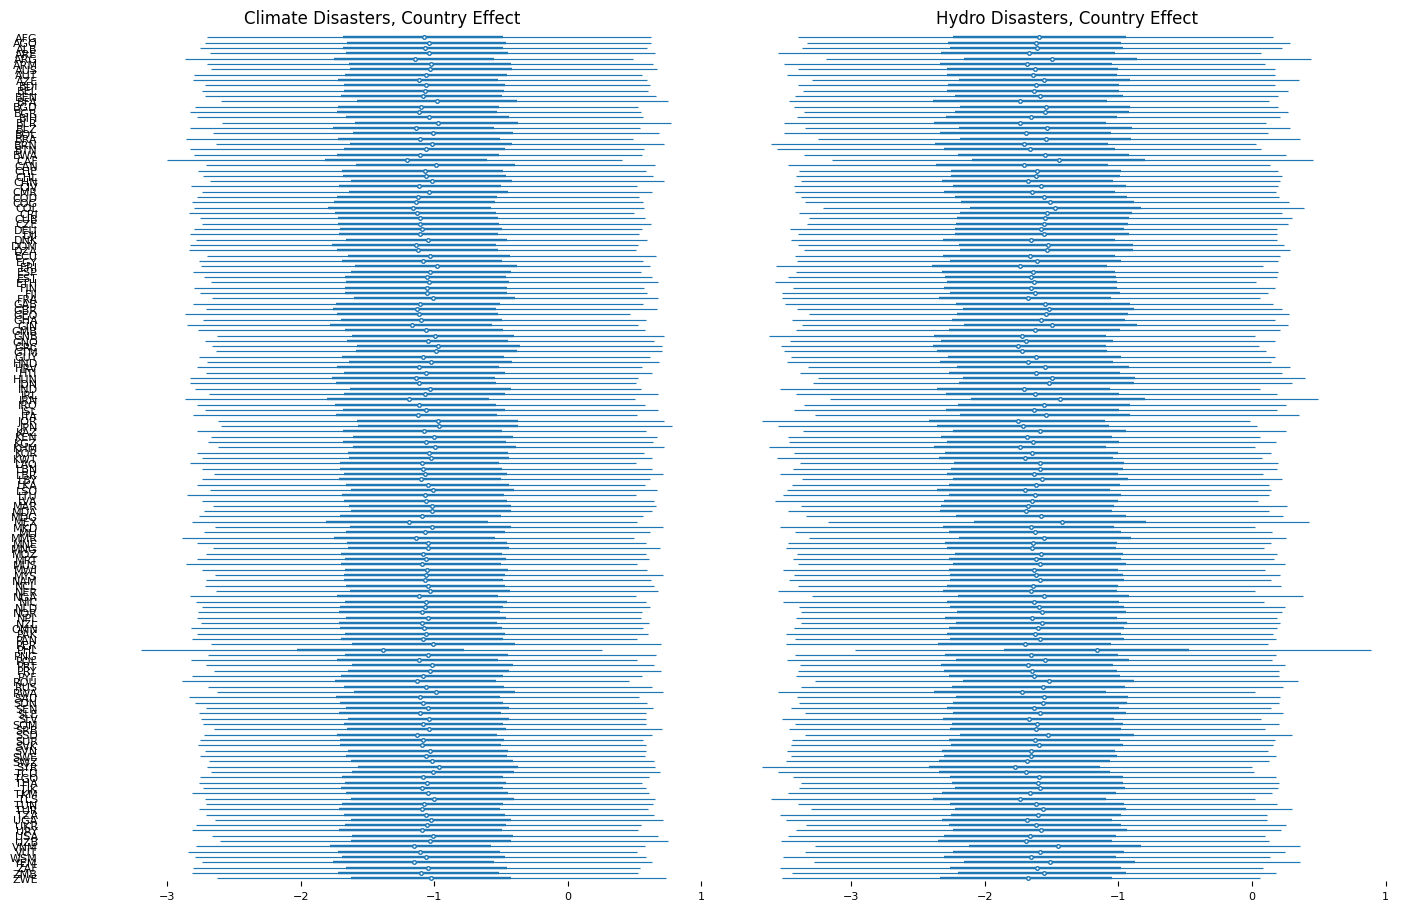

In [37]:
fig, ax = plt.subplots(1, 2, figsize=(14, 9), sharex=True, sharey=True)
for axis, disaster in zip(fig.axes, coords['disaster']):
    az.plot_forest(idata, var_names=['country_effect'], 
                   combined=True, 
                   labeller=az.labels.NoVarLabeller(),
                   coords={'disaster':[disaster]},
                   ax=axis,
                   textsize=8)
    axis.set_title(disaster.title() + " Disasters, Country Effect")

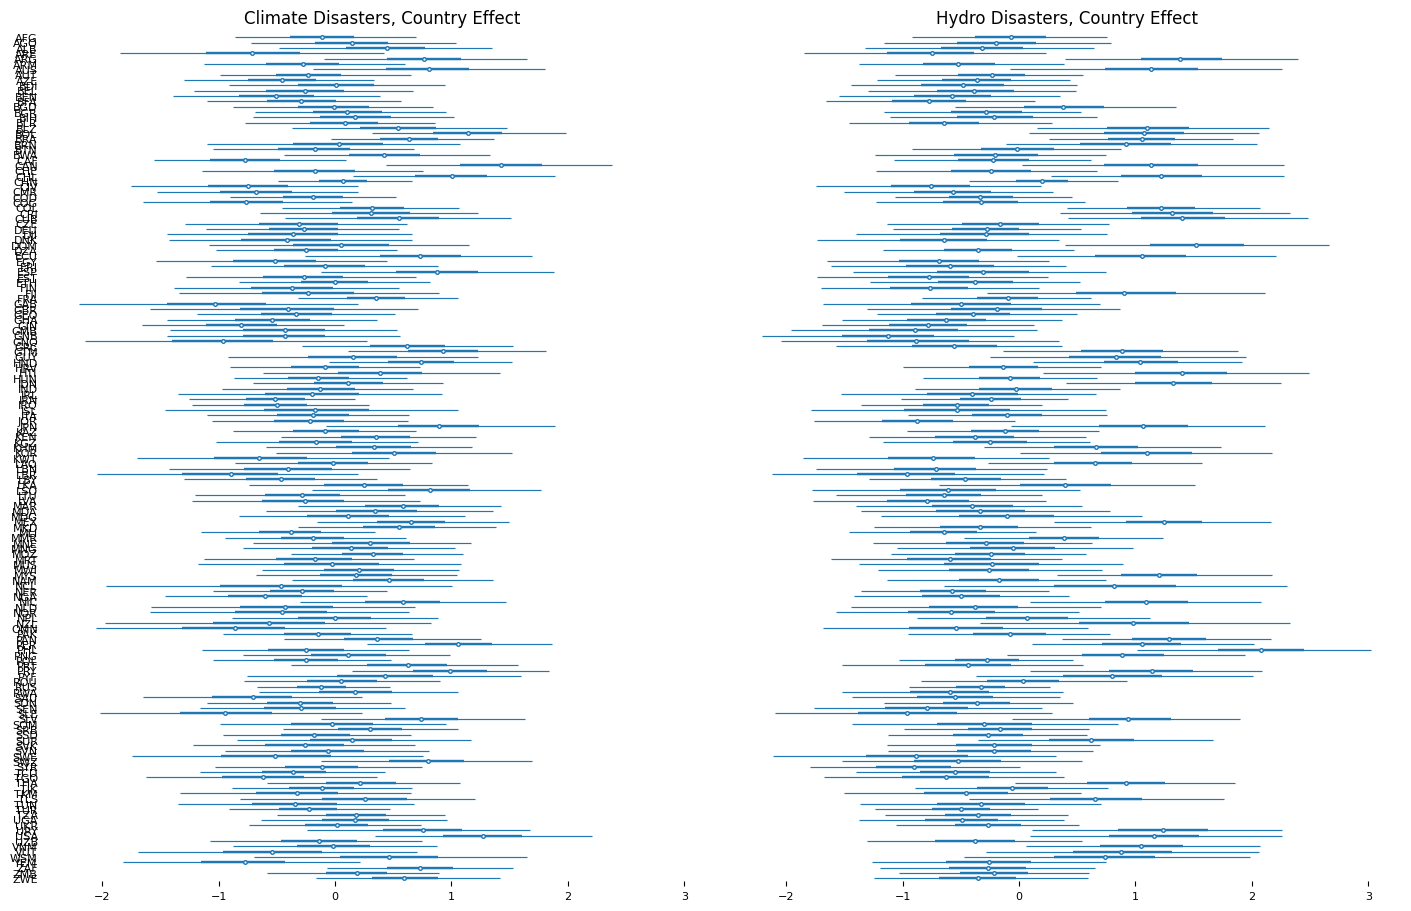

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(14, 9), sharex=True, sharey=True)
for axis, disaster in zip(fig.axes, coords['disaster']):
    az.plot_forest(idata, var_names=['phi'], 
                   combined=True, 
                   labeller=az.labels.NoVarLabeller(),
                   coords={'disaster':[disaster]},
                   ax=axis,
                   textsize=8)
    axis.set_title(disaster.title() + " Disasters, Country Effect")

In [39]:
with pm.do(model4, {'rho':[1, 1]}):
    rho_1_post = pm.sample_posterior_predictive(idata, var_names=['mixture'])

Sampling: []


Output()

In [40]:
iso_mean = (rho_1_post.posterior_predictive
                .mixture
                .mean(dim=['chain', 'draw'])
                .to_dataframe()
                .loc[:, 'mixture']
                .unstack('disaster'))

d = iso_mean.to_dict()

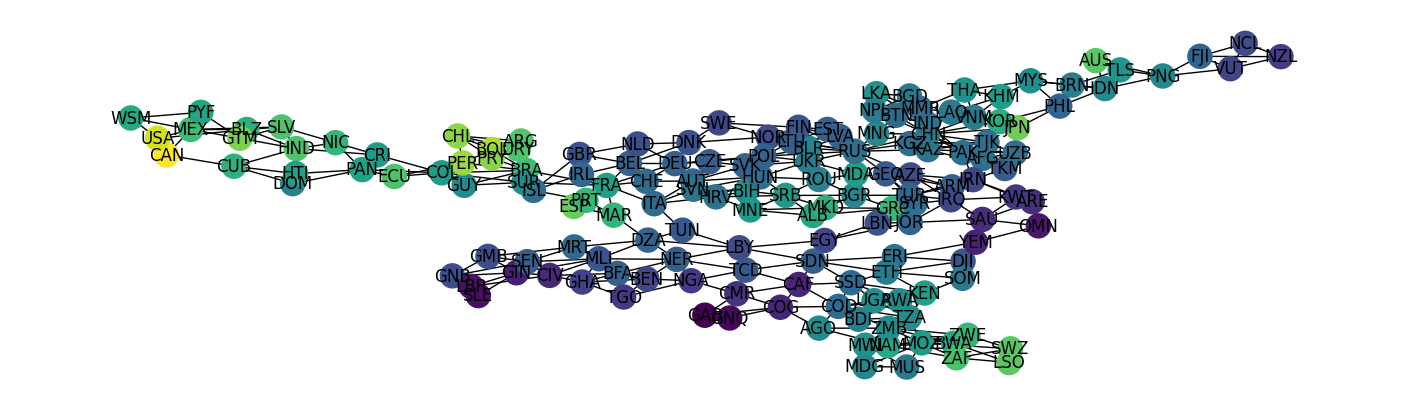

In [41]:
from networkx.drawing.nx_pydot import graphviz_layout
pos = graphviz_layout(G, prog='neato')
nx.draw_networkx(G, pos=pos, node_color=[d['climate'].get(n) for n in G.nodes])

In [42]:
world_pos = {iso: (v['x'], v['y']) for iso, v in (world.centroid
                 .apply(lambda x: pd.Series({'x':x.x, 'y':x.y}))
                 .T
                 .to_dict()).items()}

C:\Users\camil\AppData\Local\Temp\ipykernel_43564\569447385.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  world_pos = {iso: (v['x'], v['y']) for iso, v in (world.centroid


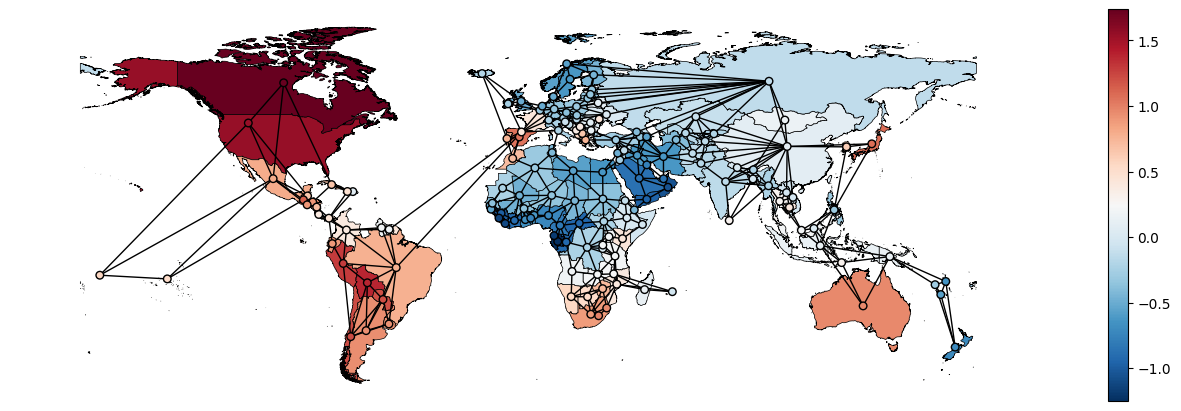

In [43]:
fig, ax = plt.subplots()
world.join(iso_mean).plot('climate', legend=True, cmap='RdBu_r', edgecolor='k', lw=0.5, ax=ax)
nx.draw_networkx_nodes(G, 
                 pos=world_pos, 
                 node_color=[d['climate'].get(n) for n in G.nodes], 
                 edgecolors='k',
                 node_size=30,
                 cmap='RdBu_r')
nx.draw_networkx_edges(G, 
                 pos=world_pos, 
                 edge_color='k')

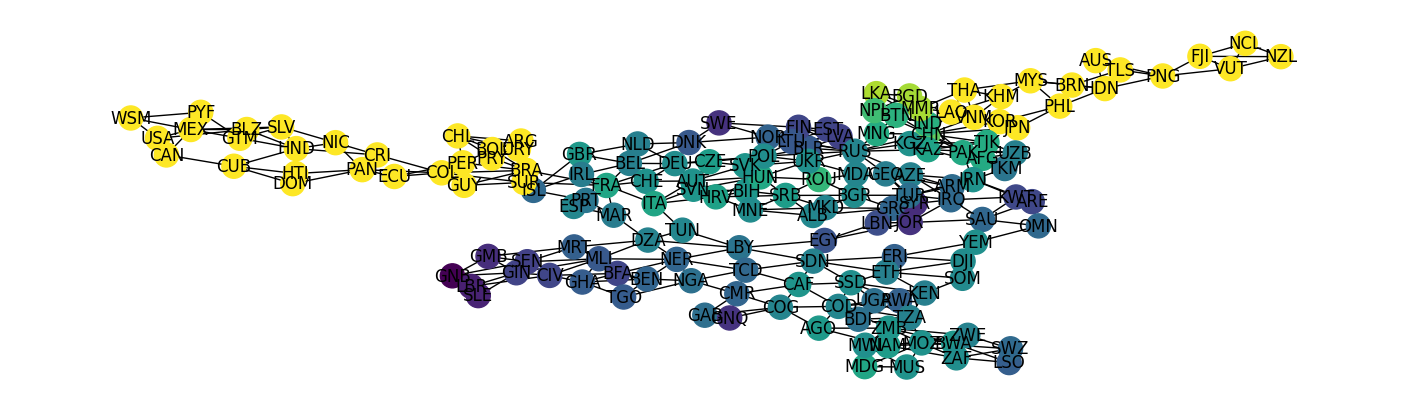

In [44]:
from networkx.drawing.nx_pydot import graphviz_layout
pos = graphviz_layout(G, prog='neato')
nx.draw_networkx(G, pos=pos, node_color=[d['hydro'].get(n) for n in G.nodes], vmax=0.75)

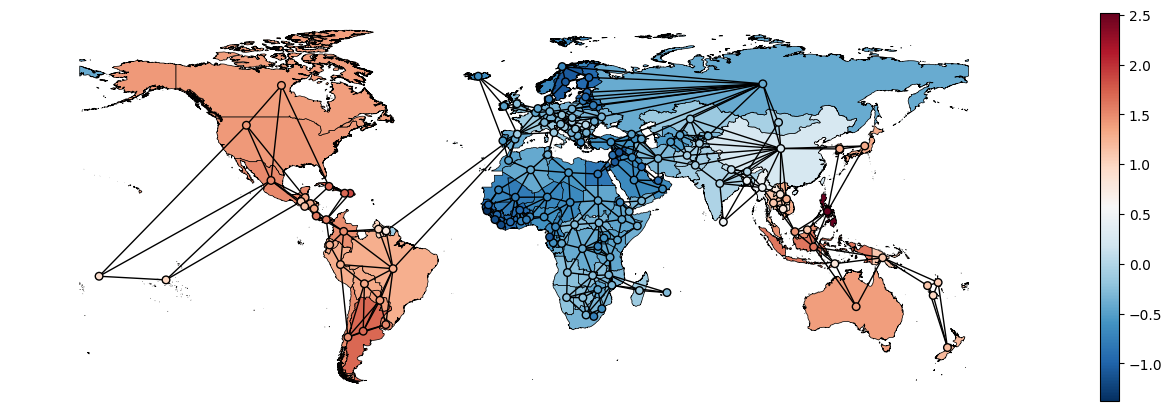

In [45]:
fig, ax = plt.subplots()
world.join(iso_mean).plot('hydro', legend=True, cmap='RdBu_r', edgecolor='k', lw=0.5, ax=ax)
nx.draw_networkx_nodes(G, 
                 pos=world_pos, 
                 node_color=[d['hydro'].get(n) for n in G.nodes], 
                 edgecolors='k',
                 node_size=30,
                 cmap='RdBu_r')
nx.draw_networkx_edges(G, 
                 pos=world_pos, 
                 edge_color='k')

In [46]:
az.compare(results, var_name='y_hat')

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
model4,0,-6589.132236,211.523929,0.000000,0.969809,93.932296,0.000000,False,log
model3,1,-6593.007988,211.330963,3.875752,0.030191,93.954756,2.882715,False,log
